# Wish Seller Anomaly — EDA

Exploring the raw Wish "summer products" dataset, the 5 engineered behavioral
features, and a sanity check of what the trained detectors actually flag.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

from data.data import load

DATA_PATH = os.path.join('..', 'data', 'summer-products-with-rating-and-performance_2020-08.csv')
df = load(DATA_PATH)
df.shape

(1014, 14)

In [2]:
df.columns

Index(['price', 'retail_price', 'units_sold', 'uses_ad_boosts', 'rating',
       'rating_count', 'merchant_rating', 'merchant_rating_count',
       'countries_shipped_to', 'badges_count', 'badge_fast_shipping',
       'shipping_option_price', 'title_orig', 'merchant_name'],
      dtype='str')

## Raw data overview

1,014 products survive `data.load()`'s cleaning (dropping rows with missing
core numeric fields, and rows where `retail_price < price`). Volume fields
are heavily right-skewed: median `units_sold` is 1,000 but the max is
100,000, and only ~1.7% of products cross 50,000 units sold — those
few extreme-volume rows turn out to matter a lot below.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)

raw_cols = ["price", "retail_price", "units_sold", "rating", "rating_count", "merchant_rating"]
df[raw_cols].describe()

Matplotlib is building the font cache; this may take a moment.


,price,retail_price,units_sold,rating,rating_count,merchant_rating
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,7.444527,31.301775,4106.886588,3.832140,833.313609,4.033133
std,3.854226,35.269120,9898.194413,0.545529,2064.350677,0.197679
min,1.000000,1.000000,1.000000,1.000000,0.000000,2.941176
25%,5.000000,6.000000,100.000000,3.510000,20.250000,3.916933
50%,7.000000,17.000000,1000.000000,3.870000,117.500000,4.040595
75%,9.000000,47.750000,5000.000000,4.130000,668.750000,4.166509
max,26.000000,252.000000,100000.000000,5.000000,20744.000000,4.577519


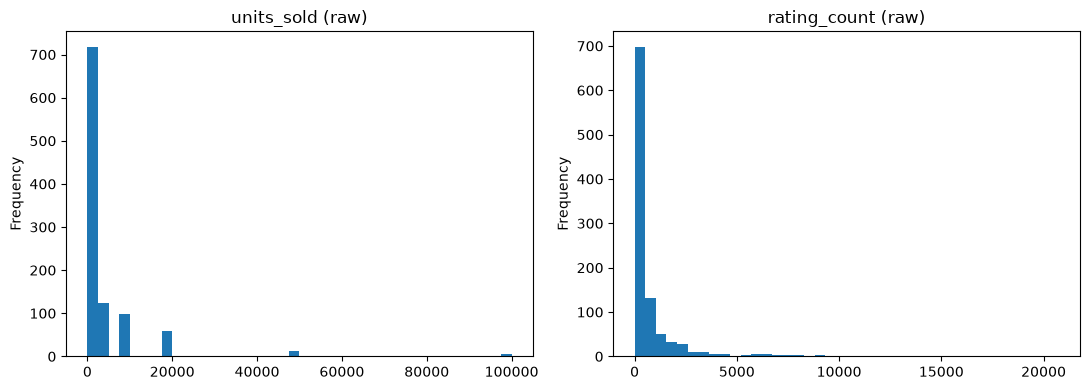

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["units_sold"].plot(kind="hist", bins=40, ax=axes[0], title="units_sold (raw)")
df["rating_count"].plot(kind="hist", bins=40, ax=axes[1], title="rating_count (raw)")
plt.tight_layout()
plt.show()

## Engineered features

The 5 behavioral signals from `src.features.engineer`. Before trusting them,
it's worth checking they're not secretly measuring the same thing twice — if
two features are highly correlated, the model ends up counting one real
signal as if it were two, which skews its anomaly scores toward whatever
pattern those correlated features share.

In [5]:
from src.features import engineer, FEATURE_COLS

feats = engineer(df)
feats.describe()

,discount_rate,review_to_sales_ratio,ad_efficiency,rating_quality,merchant_trust_gap
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,0.479280,0.249516,3285.752465,18.067991,-0.200993
std,0.352532,0.229806,8481.393201,9.203572,0.544436
min,0.000000,0.000000,1.000000,0.000000,-2.515748
25%,0.088958,0.107279,50.000000,11.114001,-0.483111
50%,0.561635,0.182800,500.000000,17.846780,-0.190136
75%,0.820000,0.316832,2500.000000,25.306149,0.049106
max,0.969286,2.000000,100000.000000,40.754248,1.791039


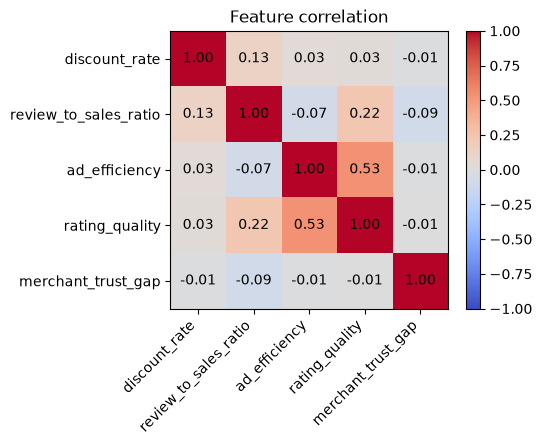

In [6]:
import numpy as np

corr = feats.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(FEATURE_COLS)), FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURE_COLS)), FEATURE_COLS)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
fig.colorbar(im)
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

The 5 features are essentially uncorrelated (all `|corr| < 0.15`), so each is
contributing distinct information to the detectors rather than redundantly
restating the same underlying signal.

## Sanity-checking the flagged anomalies

There's no ground-truth "this seller is fraudulent" label in this dataset, so
the only way to validate an unsupervised model is to manually inspect what it
flags and ask whether the story makes sense. Run `make train` first so
`models/scored_products.csv` exists.

In [7]:
scored = pd.read_csv("../models/scored_products.csv")

print("IF vs Mahalanobis flag overlap:")
print(pd.crosstab(scored["if_flag"], scored["mh_flag"]))

display_cols = ["title_orig", "price", "retail_price", "units_sold",
                 "rating", "rating_count", "merchant_rating", "uses_ad_boosts"]

scored.sort_values("if_score", ascending=False)[display_cols + ["if_score"]].head(10)

IF vs Mahalanobis flag overlap:
mh_flag  False  True 
if_flag              
False      999      4
True         4      7


,title_orig,price,retail_price,units_sold,rating,rating_count,merchant_rating,uses_ad_boosts,if_score
58,Women Stretchy Camisole Spaghetti Strap Long T...,5.77,48,100000,4.10,20744,4.067348,0,0.058906
158,Womens Summer Red White and Blue Chiffon Short...,5.00,33,100000,3.98,13789,4.036081,0,0.056012
745,Women's Summer Sexy Sleeveless Turtleneck Mini...,5.67,19,100000,3.53,18393,3.889131,0,0.035733
604,Sexy Womens Short Sleeve Party Evening Crew Ne...,6.00,6,50000,4.20,12880,4.227943,0,0.030755
324,Women Fashion Sexy Sleeveless Knit Crop Tops,3.00,3,50000,3.81,11408,4.049157,0,0.016752
758,Crystal Sequins Anklet Set for Women Beach Foo...,2.00,2,50000,4.01,7575,4.165079,0,0.015174
490,Plus Size Fashion Sleeveless Tank Tops For Wom...,4.00,6,50000,4.00,10927,4.094694,0,0.013511
209,Summer Women Chiffon Solid Color O-neck Sleeve...,5.00,5,50000,3.93,7088,4.095288,0,0.010876
27,Sexy Women Casual Striped T-shirt Long Tops Bl...,9.00,81,50000,4.26,5359,4.105054,0,0.008660
642,Women Lace Short Sleeve Long Tops Blouse Shirt...,7.00,22,100000,3.82,11913,4.218866,1,0.002039


Each detector flags about 1% of the products (11 out of 1,014). This is
expected, because we set `contamination=0.01`.

But here is something more useful: 7 of these 11 products are flagged by
**both** detectors. Isolation Forest and Mahalanobis distance work in
different ways (one is density-based, the other is distance-based). So if
they agree on the same products, that is a good sign. It probably means they
are finding a real pattern, not just random noise.

What are they actually finding? I looked at the top products flagged by
Isolation Forest. All of them have a very high `units_sold` (50,000 to
100,000), while the median in this dataset is only 1,000. They also have a
very high `rating_count`, in the thousands, while the median is about 118.
So these products are extreme in both sales and reviews at the same time.
This combination is rare in the rest of the catalog.

Is this fraud? I cannot say for sure. It could mean fake reviews and fake
sales (bot activity). But it could also just mean these are the most popular
products in the catalog. This dataset does not give us enough information to
know which one is true. This is the main limit of an unsupervised approach:
it gives us a short list of products to check manually, not a final answer.

## Limitations

- **No labels.** I do not have real data about which sellers are actually
  fraudulent. So everything above is "this looks suspicious," not a
  measured accuracy score. To really test this, we would need labeled data,
  or feedback from a trust & safety team.
- **`ad_efficiency` is a weak feature.** The dataset only tells us if a
  seller used ads or not (yes/no). It does not tell us how much they spent
  on ads. So this feature can only show "used ads but still sold badly." It
  cannot show real wasted ad spend.
- **The 1% contamination value is a guess.** I used `contamination=0.01` as
  a starting point. I do not actually know that 1% of the products are
  anomalous. This number should be adjusted later, based on real labels or
  business needs.
- **Drift monitoring is not tested with real drift.** `src/drift.py`
  calculates PSI (Population Stability Index), and it is used in the
  dashboard. But there is no real live traffic here. I only split this same
  dataset into groups to show that the method works. It does not detect
  real drift over time.